# Model 1A, Ensemble Experiment 01: CatBoost and MLP Probability Blend

This append-only experiment tests whether two completed nonlinear departure models make sufficiently different errors for a simple probability blend to improve ranking or calibration. The CatBoost component is Experiment 04's selected 41-field rotation, compact airport-wide W60, and same-airline W60 design. The MLP component is Experiment 02's 36-field rotation and compact airport-wide W60 design.

Both models regenerate aligned held-out probabilities from the same five expanding chronological folds within 2019. Five predeclared convex weights range from pure CatBoost to pure MLP. Mean fold average precision selects the weight, and the selected blend's F1 threshold is chosen from aggregated held-out 2019 probabilities. Both components are then refitted on all 2019 rows and evaluated once on 2023. No prediction file or combined feature dataset is written, and 2024 is never loaded. The final-tail assignment caveat applies to both components and the blend.


In [1]:
import gc
import os
from pathlib import Path
from time import perf_counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-capstone")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/xdg-cache-capstone")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow import keras
from tensorflow.keras import layers, regularizers

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5

# Fixed CatBoost 04 component.
CATBOOST_ITERATIONS = 683
CATBOOST_DEPTH = 6
CATBOOST_LEARNING_RATE = 0.03
CATBOOST_L2 = 3
N_JOBS = 4

# Fixed MLP 02 component.
MLP_HIDDEN_UNITS = (64, 32)
MLP_LEARNING_RATE = 0.001
MLP_L2 = 0.0001
MLP_BATCH_SIZE = 512
MLP_EPOCHS = 16

CATBOOST_WEIGHTS = [1.00, 0.75, 0.50, 0.25, 0.00]

tf.keras.utils.set_random_seed(RANDOM_STATE)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost {catboost.__version__}; TensorFlow {tf.__version__}; scikit-learn {sklearn.__version__}")


CatBoost 1.2.10; TensorFlow 2.21.0; scikit-learn 1.9.0


The blend introduces no learned meta-model and no 2023-driven weight search. For CatBoost weight `w`, the predicted delay probability is `w * CatBoost + (1 - w) * MLP`. Pure-component weights are included as internal controls, so the blend is promoted only if a mixed weight improves the 2019 selection measure.


## Pair and validate the three established feature paths

Full-history rotation, airport-wide W60 backlog, and same-airline W60 backlog files are loaded separately and paired only after strict three-way row-identity checks. The MLP ignores the same-airline columns by design; the data path is still validated once for both components.


In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames, airline_backlog_frames = {}, {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    feature_dir = PROJECT_ROOT / "data/features"
    rotation_path = feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    airline_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    airline_backlog_frames[partition] = pd.read_csv(airline_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} airport backlog rows <- {backlog_path.name}")
    print(f"{'':10s}  {len(airline_backlog_frames[partition]):,} airline backlog rows <- {airline_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 airport backlog rows <- JFK_2019_departures_backlog_w60.csv
            107,430 airline backlog rows <- JFK_2019_departures_backlog_airline_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 airport backlog rows <- JFK_2023_departures_backlog_w60.csv
            109,983 airline backlog rows <- JFK_2023_departures_backlog_airline_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation = rotation_frames[partition]
    backlog = backlog_frames[partition]
    airline_backlog = airline_backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    required_airline = {"FlightDate", "DATE", "Origin", TARGET, *FULL_AIRLINE_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert not required_airline.difference(airline_backlog.columns)
    assert len(rotation) == len(backlog) == len(airline_backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline_backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    airline_backlog["FlightDate"] = pd.to_datetime(airline_backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    airline_cutoff = pd.to_datetime(airline_backlog["DATE"], errors="raise")
    pd.testing.assert_series_equal(cutoff, airline_cutoff, check_names=False)
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()

    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1

    airline_scheduled, airline_completed, airline_pending, airline_delayed = (
        pd.to_numeric(airline_backlog[column], errors="raise")
        for column in FULL_AIRLINE_BACKLOG_FEATURES[:4]
    )
    airline_share = pd.to_numeric(airline_backlog[FULL_AIRLINE_BACKLOG_FEATURES[-1]], errors="coerce")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()
    has_airline_history = airline_scheduled.gt(0)
    assert airline_share.loc[~has_airline_history].isna().all()
    assert np.allclose(
        airline_share.loc[has_airline_history],
        airline_pending.loc[has_airline_history] / airline_scheduled.loc[has_airline_history],
    )
    normalized_airline = airline_backlog["Reporting_Airline"].astype("string").str.strip().str.upper()
    same_airline_cutoff_variants = (airline_backlog.assign(_CUTOFF=airline_cutoff, _AIRLINE=normalized_airline)
        .groupby(["_AIRLINE", "_CUTOFF"], sort=False)[FULL_AIRLINE_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_airline_cutoff_variants <= 1

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline_backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_airport_pending": pending.mean(),
        "mean_airline_pending": airline_pending.mean(),
        "airline_pending_rows": int(airline_pending.gt(0).sum()),
        "airport_cutoff_violations": int(same_cutoff_variants > 1),
        "airline_cutoff_violations": int(same_airline_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_airport_pending,mean_airline_pending,airline_pending_rows,airport_cutoff_violations,airline_cutoff_violations
partition,,,,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0.5685,36464,0,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0.7171,43531,0,0


## Apply the 24-hour mask and define both completed model manifests

The CatBoost component receives 41 source fields: six native categorical fields and 35 numeric fields including five same-airline W60 fields. The MLP receives its original 36 source fields: the same six categories and 30 numeric fields without the airline extension. Both use the identical target rows and long-turn mask.


In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
mlp_numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
catboost_numeric_features = [*mlp_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES]
mlp_features = [*categorical_features, *mlp_numeric_features]
catboost_features = [*categorical_features, *catboost_numeric_features]
required_columns = list(dict.fromkeys([
    "FlightDate", "CRSDepTime", TARGET, *categorical_features, *catboost_numeric_features
]))
assert len(categorical_features) == 6
assert len(mlp_numeric_features) == 30 and len(mlp_features) == 36
assert len(catboost_numeric_features) == 35 and len(catboost_features) == 41
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(catboost_features)
pd.DataFrame({
    "CatBoost 04": {"source fields": len(catboost_features), "categorical": len(categorical_features),
                    "numeric": len(catboost_numeric_features)},
    "MLP 02": {"source fields": len(mlp_features), "categorical": len(categorical_features),
               "numeric": len(mlp_numeric_features)},
}).T


,source fields,categorical,numeric
CatBoost 04,41,6,35
MLP 02,36,6,30


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(np.float32)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in catboost_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
X_train_catboost = train_model_df[catboost_features].reset_index(drop=True)
X_validation_catboost = validation_model_df[catboost_features].reset_index(drop=True)
X_train_mlp = train_model_df[mlp_features].reset_index(drop=True)
X_validation_mlp = validation_model_df[mlp_features].reset_index(drop=True)
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": train_model_df[catboost_numeric_features].isna().sum(),
    "validation_missing": validation_model_df[catboost_numeric_features].isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28
ROTATION_MATCH_FOUND,8281,8409
ROTATION_SCHEDULED_TURN_MINUTES,11877,13310
ROTATION_INBOUND_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_OVERDUE_MINUTES,11877,13310


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Define the fixed CatBoost and MLP components

CatBoost exactly reproduces Experiment 04. The MLP exactly reproduces Experiment 02's fold-local one-hot encoding, median imputation with missing indicators, scaling, `(64, 32)` architecture, regularization, batch size, epoch count, and fold seeds. Neither component is retuned in this experiment.


In [7]:
def make_catboost_model(seed=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=CATBOOST_ITERATIONS, loss_function="Logloss", eval_metric="PRAUC:type=Classic",
        depth=CATBOOST_DEPTH, learning_rate=CATBOOST_LEARNING_RATE,
        l2_leaf_reg=CATBOOST_L2, random_seed=seed,
        thread_count=N_JOBS, allow_writing_files=False, verbose=False,
    )


def make_mlp_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    return ColumnTransformer([
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False,
                                      dtype=np.float32), categorical_features),
        ("numeric", numeric_pipeline, mlp_numeric_features),
    ], sparse_threshold=0.0, verbose_feature_names_out=True)


def build_mlp(input_width, seed):
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(input_width,), name="prepared_features")
    x = inputs
    for layer_number, units in enumerate(MLP_HIDDEN_UNITS):
        x = layers.Dense(
            units, activation="relu", kernel_regularizer=regularizers.l2(MLP_L2),
            name=f"dense_{layer_number + 1}",
        )(x)
        x = layers.BatchNormalization(name=f"batch_norm_{layer_number + 1}")(x)
        dropout_rate = 0.25 if layer_number == 0 else 0.20
        x = layers.Dropout(dropout_rate, seed=seed + layer_number,
                           name=f"dropout_{layer_number + 1}")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="delay_probability")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=MLP_LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="pr_auc", curve="PR"),
                 keras.metrics.AUC(name="roc_auc", curve="ROC")],
    )
    return model


## Generate aligned 2019 held-out probabilities and select the weight

Each fold fits both components only on its earlier block and predicts the identical later block. Candidate blends are scored separately within each fold. Mean fold AP is the primary weight-selection measure, with mean ROC AUC and greater CatBoost weight as deterministic tie-breakers.


In [8]:
oof_start = perf_counter()
catboost_oof = np.full(len(y_train), np.nan)
mlp_oof = np.full(len(y_train), np.nan)
component_fold_rows = []
for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
    catboost_model = make_catboost_model(RANDOM_STATE)
    catboost_model.fit(
        X_train_catboost.iloc[train_idx], y_train.iloc[train_idx],
        cat_features=categorical_features, verbose=False,
    )
    catboost_probabilities = catboost_model.predict_proba(
        X_train_catboost.iloc[heldout_idx]
    )[:, 1]
    catboost_oof[heldout_idx] = catboost_probabilities

    preprocessor = make_mlp_preprocessor()
    fold_train_x = np.asarray(preprocessor.fit_transform(X_train_mlp.iloc[train_idx]), dtype=np.float32)
    fold_heldout_x = np.asarray(preprocessor.transform(X_train_mlp.iloc[heldout_idx]), dtype=np.float32)
    mlp_model = build_mlp(fold_train_x.shape[1], RANDOM_STATE + 100 + fold_number)
    mlp_model.fit(
        fold_train_x, y_train.iloc[train_idx].to_numpy(dtype=np.float32),
        epochs=MLP_EPOCHS, batch_size=MLP_BATCH_SIZE, verbose=0,
    )
    mlp_probabilities = mlp_model.predict(fold_heldout_x, batch_size=2048, verbose=0).ravel()
    mlp_oof[heldout_idx] = mlp_probabilities

    fold_y = y_train.iloc[heldout_idx]
    component_fold_rows.extend([
        {"component": "CatBoost 04", "fold": fold_number,
         "average_precision": average_precision_score(fold_y, catboost_probabilities),
         "roc_auc": roc_auc_score(fold_y, catboost_probabilities),
         "brier_score": brier_score_loss(fold_y, catboost_probabilities)},
        {"component": "MLP 02", "fold": fold_number,
         "average_precision": average_precision_score(fold_y, mlp_probabilities),
         "roc_auc": roc_auc_score(fold_y, mlp_probabilities),
         "brier_score": brier_score_loss(fold_y, mlp_probabilities)},
    ])
    print(f"Completed aligned component fold {fold_number}/{N_TIME_SPLITS}")
    del catboost_model, preprocessor, fold_train_x, fold_heldout_x, mlp_model
    keras.backend.clear_session(); gc.collect()

oof_seconds = perf_counter() - oof_start
blend_fold_rows = []
for catboost_weight in CATBOOST_WEIGHTS:
    for fold_number, (_, heldout_idx) in enumerate(temporal_splits, start=1):
        probabilities = (
            catboost_weight * catboost_oof[heldout_idx]
            + (1 - catboost_weight) * mlp_oof[heldout_idx]
        )
        fold_y = y_train.iloc[heldout_idx]
        blend_fold_rows.append({
            "catboost_weight": catboost_weight, "mlp_weight": 1 - catboost_weight,
            "fold": fold_number,
            "average_precision": average_precision_score(fold_y, probabilities),
            "roc_auc": roc_auc_score(fold_y, probabilities),
            "brier_score": brier_score_loss(fold_y, probabilities),
        })
blend_fold_results = pd.DataFrame(blend_fold_rows)
blend_results = (blend_fold_results
    .groupby(["catboost_weight", "mlp_weight"], as_index=False)
    .agg(mean_average_precision=("average_precision", "mean"),
         std_average_precision=("average_precision", "std"),
         mean_roc_auc=("roc_auc", "mean"), mean_brier_score=("brier_score", "mean"))
    .sort_values(["mean_average_precision", "mean_roc_auc", "catboost_weight"], ascending=False))
selected_catboost_weight = float(blend_results.iloc[0]["catboost_weight"])
selected_mlp_weight = 1 - selected_catboost_weight
print(f"Aligned OOF fitting completed in {oof_seconds:,.1f} seconds")
print(f"Selected blend: {selected_catboost_weight:.2f} CatBoost + {selected_mlp_weight:.2f} MLP")
display(pd.DataFrame(component_fold_rows).groupby("component").agg(
    mean_average_precision=("average_precision", "mean"),
    mean_roc_auc=("roc_auc", "mean"), mean_brier_score=("brier_score", "mean")))
display(blend_results)
blend_fold_results.pivot(index="fold", columns="catboost_weight", values="average_precision")


Completed aligned component fold 1/5


Completed aligned component fold 2/5


Completed aligned component fold 3/5


Completed aligned component fold 4/5


Completed aligned component fold 5/5


Aligned OOF fitting completed in 93.8 seconds
Selected blend: 0.75 CatBoost + 0.25 MLP


,mean_average_precision,mean_roc_auc,mean_brier_score
component,,,
CatBoost 04,0.7018,0.8448,0.0916
MLP 02,0.6934,0.8383,0.0933


,catboost_weight,mlp_weight,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score
3,0.7500,0.2500,0.7047,0.0605,0.8467,0.0911
2,0.5000,0.5000,0.7044,0.0599,0.8463,0.0912
4,1.0000,0.0000,0.7018,0.0615,0.8448,0.0916
1,0.2500,0.7500,0.7007,0.0599,0.8438,0.0919
0,0.0000,1.0000,0.6934,0.0604,0.8383,0.0933


catboost_weight,0.0000,0.2500,0.5000,0.7500,1.0000
fold,,,,,
1,0.6570,0.6668,0.6697,0.6677,0.6620
2,0.7272,0.7344,0.7388,0.7402,0.7381
3,0.7817,0.7880,0.7913,0.7920,0.7905
4,0.6324,0.6390,0.6428,0.6432,0.6404
5,0.6684,0.6751,0.6793,0.6805,0.6778


## Select operating thresholds using 2019 only

Every candidate weight receives an F1 threshold from its aggregated held-out 2019 probabilities. The selected blend is determined by mean fold AP before its threshold or any 2023 result is examined.


In [9]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold, "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_mask = np.isfinite(catboost_oof) & np.isfinite(mlp_oof)
oof_y = y_train.to_numpy()[oof_mask]
weight_thresholds, threshold_rows, aggregate_oof_rows = {}, [], []
for catboost_weight in CATBOOST_WEIGHTS:
    probabilities = (
        catboost_weight * catboost_oof[oof_mask]
        + (1 - catboost_weight) * mlp_oof[oof_mask]
    )
    candidate_rows = [
        {"catboost_weight": catboost_weight, **evaluate_probabilities(oof_y, probabilities, threshold)}
        for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
    ]
    threshold_rows.extend(candidate_rows)
    best = pd.DataFrame(candidate_rows).sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]
    weight_thresholds[catboost_weight] = float(best["threshold"])
    aggregate_oof_rows.append({
        "catboost_weight": catboost_weight, "mlp_weight": 1 - catboost_weight,
        "selected_threshold": weight_thresholds[catboost_weight],
        "aggregate_average_precision": average_precision_score(oof_y, probabilities),
        "aggregate_roc_auc": roc_auc_score(oof_y, probabilities),
        "aggregate_brier_score": brier_score_loss(oof_y, probabilities),
        "selected_threshold_f1": best["f1"], "selected_threshold_mcc": best["mcc"],
    })
selected_threshold = weight_thresholds[selected_catboost_weight]
threshold_results = pd.DataFrame(threshold_rows)
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Selected blend threshold: {selected_threshold:.2f}")
pd.DataFrame(aggregate_oof_rows).sort_values("catboost_weight", ascending=False)


Threshold-selection rows: 89,693
Selected blend threshold: 0.31


,catboost_weight,mlp_weight,selected_threshold,aggregate_average_precision,aggregate_roc_auc,aggregate_brier_score,selected_threshold_f1,selected_threshold_mcc
0,1.0000,0.0000,0.3100,0.7142,0.8490,0.0916,0.6296,0.5553
1,0.7500,0.2500,0.3100,0.7174,0.8511,0.0911,0.6319,0.5608
2,0.5000,0.5000,0.2800,0.7169,0.8509,0.0912,0.6321,0.5550
3,0.2500,0.7500,0.2800,0.7126,0.8483,0.0919,0.6269,0.5502
4,0.0000,1.0000,0.3000,0.7042,0.8427,0.0933,0.6185,0.5472


## Refit both components on all 2019 rows and evaluate 2023 once

No 2023 outcome influences either component, the blend weight, or any threshold. The final table reports both pure controls and the selected blend on identical validation rows.


In [10]:
final_fit_start = perf_counter()
final_catboost_model = make_catboost_model(RANDOM_STATE)
final_catboost_model.fit(
    X_train_catboost, y_train, cat_features=categorical_features, verbose=False,
)
catboost_validation_probabilities = final_catboost_model.predict_proba(X_validation_catboost)[:, 1]

final_mlp_preprocessor = make_mlp_preprocessor()
final_mlp_train_x = np.asarray(final_mlp_preprocessor.fit_transform(X_train_mlp), dtype=np.float32)
final_mlp_validation_x = np.asarray(final_mlp_preprocessor.transform(X_validation_mlp), dtype=np.float32)
final_mlp_model = build_mlp(final_mlp_train_x.shape[1], RANDOM_STATE + 999)
final_mlp_model.fit(
    final_mlp_train_x, y_train.to_numpy(dtype=np.float32),
    epochs=MLP_EPOCHS, batch_size=MLP_BATCH_SIZE, verbose=0,
)
mlp_validation_probabilities = final_mlp_model.predict(
    final_mlp_validation_x, batch_size=2048, verbose=0
).ravel()
final_fit_seconds = perf_counter() - final_fit_start

validation_probability_sets = {
    "CatBoost 04": catboost_validation_probabilities,
    "MLP 02": mlp_validation_probabilities,
    "Selected blend": (
        selected_catboost_weight * catboost_validation_probabilities
        + selected_mlp_weight * mlp_validation_probabilities
    ),
}
component_weights = {
    "CatBoost 04": 1.0, "MLP 02": 0.0, "Selected blend": selected_catboost_weight,
}
evaluation_rows = []
for model_name, probabilities in validation_probability_sets.items():
    model_weight = component_weights[model_name]
    model_threshold = weight_thresholds[model_weight]
    evaluation_rows.extend([
        {"model": model_name, "threshold_policy": "Default",
         **evaluate_probabilities(y_validation, probabilities, 0.50)},
        {"model": model_name, "threshold_policy": "Training-selected F1",
         **evaluate_probabilities(y_validation, probabilities, model_threshold)},
    ])
evaluation_results = pd.DataFrame(evaluation_rows).set_index(["model", "threshold_policy"])
print(f"Final component fits completed in {final_fit_seconds:,.1f} seconds")
print(f"MLP prepared inputs: {final_mlp_train_x.shape[1]:,}; trainable parameters: {final_mlp_model.count_params():,}")
evaluation_results


Final component fits completed in 33.9 seconds
MLP prepared inputs: 202; trainable parameters: 15,489


threshold  accuracy  balanced_accuracy  \
model          threshold_policy                                               
CatBoost 04    Default                  0.5000    0.8567             0.7186   
               Training-selected F1     0.3100    0.8516             0.7598   
MLP 02         Default                  0.5000    0.8545             0.7132   
               Training-selected F1     0.3000    0.8468             0.7530   
Selected blend Default                  0.5000    0.8570             0.7180   
               Training-selected F1     0.3100    0.8524             0.7595   

                                     precision  recall     f1    mcc  roc_auc  \
model          threshold_policy                                                 
CatBoost 04    Default                  0.8785  0.4567 0.6010 0.5657   0.8546   
               Training-selected F1     0.7327  0.5858 0.6511 0.5640   0.8546   
MLP 02         Default                  0.8794  0.4454 0.5913 0.5581   0.8446   
               Training-selected F1     0.7204  0.5751 0.6396 0.5495   0.8446   
Selected blend Default                  0.8843  0.4544 0.6003 0.5671   0.8544   
               Training-selected F1     0.7372  0.5834 0.6514 0.5655   0.8544   

                                     average_precision  brier_score  
model          threshold_policy                                      
CatBoost 04    Default                          0.7526       0.1086  
               Training-selected F1             0.7526       0.1086  
MLP 02         Default                          0.7405       0.1112  
               Training-selected F1             0.7405       0.1112  
Selected blend Default                          0.7532       0.1085  
               Training-selected F1             0.7532       0.1085

## Diagnose subgroup performance and component diversity

The blend is useful only if the components make sufficiently different probability errors. Correlation and absolute disagreement are reported alongside the established rotation subgroups. These are diagnostics; the weight remains selected solely by 2019 mean fold AP.


rows  prevalence  \
model          population                                          
CatBoost 04    all rows                       109983      0.2364   
               excluding NOT_ARRIVED          106418      0.2109   
               ARRIVED                         93108      0.1858   
               rotation unavailable/excluded   13310      0.3866   
MLP 02         all rows                       109983      0.2364   
               excluding NOT_ARRIVED          106418      0.2109   
               ARRIVED                         93108      0.1858   
               rotation unavailable/excluded   13310      0.3866   
Selected blend all rows                       109983      0.2364   
               excluding NOT_ARRIVED          106418      0.2109   
               ARRIVED                         93108      0.1858   
               rotation unavailable/excluded   13310      0.3866   

                                              average_precision  roc_auc  \
model          population                                                  
CatBoost 04    all rows                                  0.7526   0.8546   
               excluding NOT_ARRIVED                     0.6801   0.8317   
               ARRIVED                                   0.6633   0.8256   
               rotation unavailable/excluded             0.6995   0.7711   
MLP 02         all rows                                  0.7405   0.8446   
               excluding NOT_ARRIVED                     0.6649   0.8201   
               ARRIVED                                   0.6495   0.8132   
               rotation unavailable/excluded             0.6730   0.7532   
Selected blend all rows                                  0.7532   0.8544   
               excluding NOT_ARRIVED                     0.6811   0.8315   
               ARRIVED                                   0.6647   0.8254   
               rotation unavailable/excluded             0.6968   0.7693   

                                              brier_score  
model          population                                  
CatBoost 04    all rows                            0.1086  
               excluding NOT_ARRIVED               0.1121  
               ARRIVED                             0.1014  
               rotation unavailable/excluded       0.1871  
MLP 02         all rows                            0.1112  
               excluding NOT_ARRIVED               0.1148  
               ARRIVED                             0.1028  
               rotation unavailable/excluded       0.1989  
Selected blend all rows                            0.1085  
               excluding NOT_ARRIVED               0.1120  
               ARRIVED                             0.1010  
               rotation unavailable/excluded       0.1889

,component diversity
2019 OOF probability correlation,0.9570
2019 OOF mean absolute probability difference,0.0426
2023 probability correlation,0.9718
2023 mean absolute probability difference,0.0370


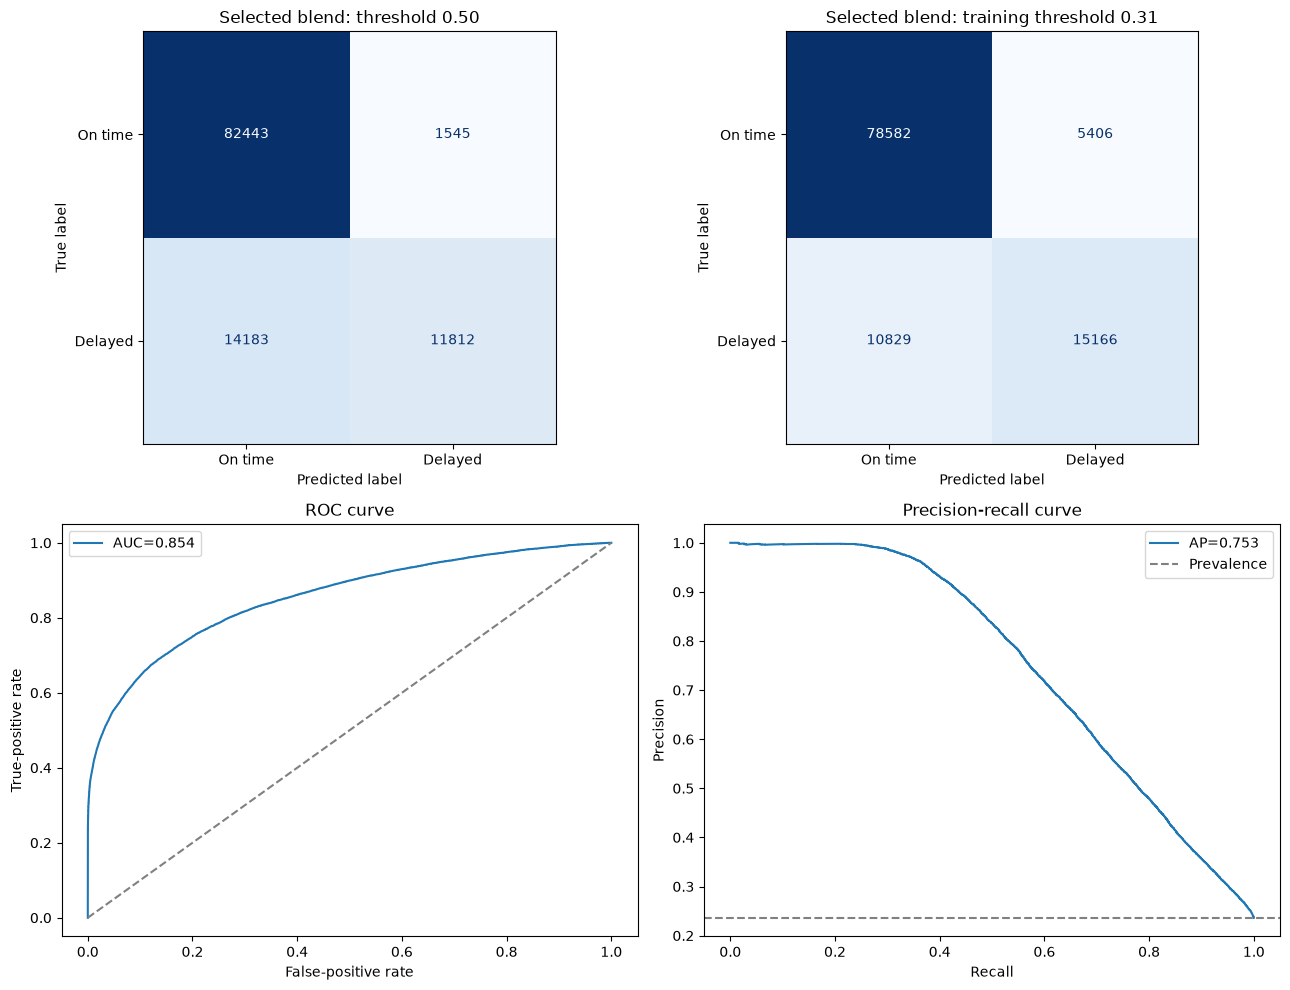

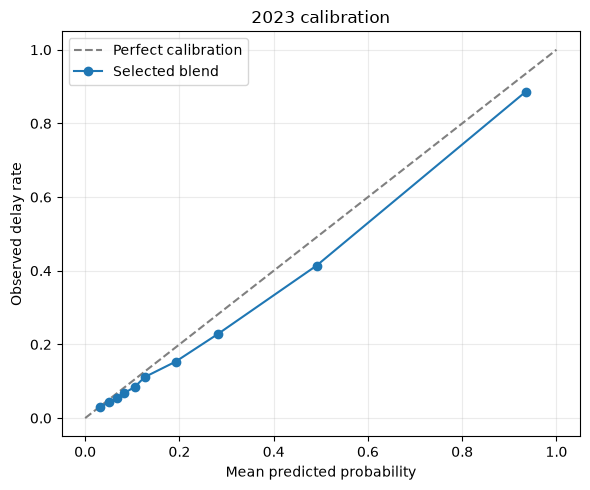

,Ensemble 1A Experiment 01 Appendix E values
selected CatBoost weight,0.7500
selected MLP weight,0.2500
selected training mean CV AP,0.7047
pure CatBoost training mean CV AP,0.7018
pure MLP training mean CV AP,0.6934
validation prevalence,0.2364
selected validation AP,0.7532
CatBoost validation AP,0.7526
MLP validation AP,0.7405
selected validation ROC AUC,0.8544


In [11]:
validation_frame = model_frames["validation"].sort_values(
    ["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
status = validation_frame["ROTATION_STATUS"].astype("string")
populations = {
    "all rows": np.ones(len(validation_frame), dtype=bool),
    "excluding NOT_ARRIVED": status.ne("NOT_ARRIVED").to_numpy(),
    "ARRIVED": status.eq("ARRIVED").to_numpy(),
    "rotation unavailable/excluded": status.isin([
        "NO_PRIOR_EVENT", "PREVIOUS_EVENT_DEPARTURE", "MISSING_TAIL", "LONG_TURN_EXCLUDED"
    ]).to_numpy(),
}
diagnostic_rows = []
for model_name, probabilities in validation_probability_sets.items():
    for population, mask in populations.items():
        subgroup_y, subgroup_p = y_validation.to_numpy()[mask], probabilities[mask]
        diagnostic_rows.append({
            "model": model_name, "population": population, "rows": int(mask.sum()),
            "prevalence": subgroup_y.mean(),
            "average_precision": average_precision_score(subgroup_y, subgroup_p),
            "roc_auc": roc_auc_score(subgroup_y, subgroup_p),
            "brier_score": brier_score_loss(subgroup_y, subgroup_p),
        })
diagnostic_results = pd.DataFrame(diagnostic_rows).set_index(["model", "population"])
display(diagnostic_results)

diversity_summary = pd.Series({
    "2019 OOF probability correlation": np.corrcoef(catboost_oof[oof_mask], mlp_oof[oof_mask])[0, 1],
    "2019 OOF mean absolute probability difference": np.mean(np.abs(catboost_oof[oof_mask] - mlp_oof[oof_mask])),
    "2023 probability correlation": np.corrcoef(catboost_validation_probabilities, mlp_validation_probabilities)[0, 1],
    "2023 mean absolute probability difference": np.mean(np.abs(catboost_validation_probabilities - mlp_validation_probabilities)),
}, name="component diversity")
display(diversity_summary.to_frame())

selected_probabilities = validation_probability_sets["Selected blend"]
default_predictions = (selected_probabilities >= 0.50).astype(int)
selected_predictions = (selected_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, selected_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, selected_probabilities)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(y_validation, default_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("Selected blend: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(y_validation, selected_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f"Selected blend: training threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate,
                label=f"AUC={roc_auc_score(y_validation, selected_probabilities):.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision,
                label=f"AP={average_precision_score(y_validation, selected_probabilities):.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
axes[1, 1].legend(); fig.tight_layout(); plt.show()

predicted, observed = calibration_curve(y_validation, selected_probabilities, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="Selected blend")
ax.set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="2023 calibration")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

selected_default = evaluation_results.loc[("Selected blend", "Default")]
selected_operating = evaluation_results.loc[("Selected blend", "Training-selected F1")]
catboost_default = evaluation_results.loc[("CatBoost 04", "Default")]
mlp_default = evaluation_results.loc[("MLP 02", "Default")]
selected_training = blend_results.set_index("catboost_weight").loc[selected_catboost_weight]
publishable_summary = pd.Series({
    "selected CatBoost weight": selected_catboost_weight,
    "selected MLP weight": selected_mlp_weight,
    "selected training mean CV AP": selected_training["mean_average_precision"],
    "pure CatBoost training mean CV AP": blend_results.set_index("catboost_weight").loc[1.0, "mean_average_precision"],
    "pure MLP training mean CV AP": blend_results.set_index("catboost_weight").loc[0.0, "mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "selected validation AP": selected_default["average_precision"],
    "CatBoost validation AP": catboost_default["average_precision"],
    "MLP validation AP": mlp_default["average_precision"],
    "selected validation ROC AUC": selected_default["roc_auc"],
    "selected validation Brier": selected_default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected_operating["accuracy"],
    "selected-threshold balanced accuracy": selected_operating["balanced_accuracy"],
    "selected-threshold precision": selected_operating["precision"],
    "selected-threshold recall": selected_operating["recall"],
    "selected-threshold F1": selected_operating["f1"],
    "selected-threshold MCC": selected_operating["mcc"],
    "selected AP excluding NOT_ARRIVED": diagnostic_results.loc[("Selected blend", "excluding NOT_ARRIVED"), "average_precision"],
    "OOF fit seconds": oof_seconds, "final fit seconds": final_fit_seconds,
}, name="Ensemble 1A Experiment 01 Appendix E values")
publishable_summary.to_frame()


## Interpretation checklist

1. Does a mixed weight improve mean 2019 temporal AP over pure CatBoost 04?
2. Does the training-selected weight preserve or improve 2023 AP, ROC AUC, and Brier score?
3. Does any gain persist after excluding `NOT_ARRIVED` and among already-arrived rotations?
4. Are component probability differences large enough to explain a blend gain?
5. Is the improvement sufficient to prefer a two-model operational pipeline over the simpler CatBoost 04 candidate?
6. Preserve the final-tail caveat: every result remains a retrospective upper bound until timestamped assignment data are available.
